### Unsupervised Anomolay Detection (Model 1) using Baseline Features 
Modified: Main Training Notebook

In [ ]:
# Install dependencies
# %pip install xgboost scikit-learn pandas numpy matplotlib seaborn

  Using cached xgboost-3.3.0-py3-none-manylinux_2_28_x86_64.whl.metadata (2.0 kB)
  Using cached nvidia_nccl_cu12-2.30.7-py3-none-manylinux_2_18_x86_64.whl.metadata (2.1 kB)
Using cached xgboost-3.3.0-py3-none-manylinux_2_28_x86_64.whl (98.7 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 303.4/303.4 MB 7.6 MB/s eta 0:00:000m eta 0:00:010:00:01
Note: you may need to restart the kernel to use updated packages.


In [1]:
import subprocess
import sys
import os
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.preprocessing import LabelEncoder

In [2]:
OUTPUT_DIR = "./saved_models"

In [3]:
def convert_and_import(notebook_name, notebook_dir="."):
    nb_path = os.path.join(notebook_dir, f"{notebook_name}.ipynb")
    if not os.path.exists(nb_path):
        raise FileNotFoundError(f"Not found: {nb_path}")
    subprocess.run(
        [sys.executable, "-m", "nbconvert", "--to", "script",
         "--output", notebook_name, nb_path],
        capture_output=True, check=True
    )
    if notebook_dir not in sys.path:
        sys.path.insert(0, notebook_dir)
    if notebook_name in sys.modules:
        mod = importlib.reload(sys.modules[notebook_name])
    else:
        mod = importlib.import_module(notebook_name)
    print(f"Done with {notebook_name}")
    return mod

In [4]:
NOTEBOOK_DIR = os.path.dirname(os.path.abspath("__file__"))

ALL_NOTEBOOKS = [
    "model_isolation_forest",
    "model_xgboost",
    "model_random_forest",
    "model_decision_tree",
    "model_knn",
    "model_mlp"
]

print("Importing notebooks...")
mods = {n: convert_and_import(n, NOTEBOOK_DIR) for n in ALL_NOTEBOOKS}

Importing notebooks...
Done with model_isolation_forest
Done with model_xgboost
Done with model_random_forest
Done with model_decision_tree
Done with model_knn
Done with model_mlp


In [5]:
if_mod = mods["model_isolation_forest"]
xgb_mod = mods["model_xgboost"]
rf_mod = mods["model_random_forest"]
dt_mod  = mods["model_decision_tree"]
knn_mod  = mods["model_knn"]
mlp_mod = mods["model_mlp"]

In [6]:
# DATA LOADING

USE_DEMO_DATA = True

if USE_DEMO_DATA:
    X_raw, y_raw_int = make_classification(
        n_samples=12_000, n_features=84, n_informative=40,
        n_classes=8, n_clusters_per_class=1, random_state=42
    )
    ATTACK_CLASSES = ["Benign", "DDoS", "DoS", "Recon",
                      "Web-based", "BruteForce", "Spoofing", "Mirai"]
    y_raw = np.array([ATTACK_CLASSES[i] for i in y_raw_int])
    X_raw = pd.DataFrame(X_raw, columns=[f"feature_{i}" for i in range(84)])

else:
    # PROCESSED DATA SHOULD BE HERE
    pass

X_temp, X_test, y_temp, y_test = train_test_split(
    X_raw, y_raw, test_size=0.15, stratify=y_raw, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15, stratify=y_temp, random_state=42
)

NORMAL_LABEL = "Benign"

print(f"Train : {X_train.shape}  |  Val : {X_val.shape}  |  Test : {X_test.shape}")
vals, counts = np.unique(y_train, return_counts=True)
for v, c in zip(vals, counts):
    print(f"  {v:15s}: {c:6,}")

Train : (8670, 84)  |  Val : (1530, 84)  |  Test : (1800, 84)
  Benign         :  1,080
  BruteForce     :  1,087
  DDoS           :  1,081
  DoS            :  1,081
  Mirai          :  1,082
  Recon          :  1,086
  Spoofing       :  1,086
  Web-based      :  1,087


### Preprocessing Phase

In [7]:
# ============================================================
# PACKET-LEVEL PREPROCESSING (unsupervised features -> Isolation Forest only)
# ============================================================
# This does NOT touch X_train/X_val/X_test above (those still feed the
# 5 supervised classifiers on flow-level data, untouched for now).
#
# Raw packet-level columns (from your actual CSV header) that we use here:
#   inter_arrival_time, jitter, payload_entropy, payload_length,
#   l3_ip_dst_count, average_p, var_p, src_ip_5_count   -> numeric, used as-is
#   dst_port                                            -> rebinned into port_class_dst
#   http_response_code                                  -> rebinned into response-class buckets
#
# NOTE: the raw file already ships a `port_class_dst` column, but we
# deliberately rebuild it from the raw `dst_port` so the bins line up with
# the 5 attacks in this project (DNS Spoofing -> 53, HTTP floods/XSS -> 80/443,
# Brute Force -> common auth/mgmt ports), rather than whatever generic
# scheme the dataset's own column used.

# --- sampled packet-level data, produced by generate_dataset.py ---
# generate_dataset.py writes to REPO_ROOT/data/sampled/packet_sample.parquet.
# This notebook lives in REPO_ROOT/notebooks, so relative to the notebook:
PACKET_SAMPLE_PATH = "../data/sampled/packet_sample.parquet"
LABEL_COL = "label"   # matches generate_dataset.py's `result["label"] = ...`

PACKET_FEATURES = [
    "inter_arrival_time",
    "jitter",
    "payload_entropy",
    "payload_length",
    "l3_ip_dst_count",
    "average_p",
    "var_p",
    "http_response_code",   # becomes an int bin code, see below
    "src_ip_5_count",
    "port_class_dst",       # becomes an int bin code, see below
]

_NUMERIC_RAW_COLS = [
    "inter_arrival_time", "jitter", "payload_entropy", "payload_length",
    "l3_ip_dst_count", "average_p", "var_p", "src_ip_5_count",
]

# Fixed (not data-fitted) category -> int maps so encoding is deterministic
# across runs/samples, regardless of which categories happen to appear.
PORT_BIN_MAP = {"dns": 0, "http": 1, "https": 2, "mgmt_auth": 3, "other": 4}
HTTP_BIN_MAP = {
    "no_response": 0, "informational": 1, "success": 2,
    "redirect": 3, "client_error": 4, "server_error": 5, "other": 6,
}


#### Binning Functions

In [8]:
# Binning functions for the two categorical features.
# NOTE: the raw file already ships a `port_class_dst` column, but we
# deliberately rebuild it from raw `dst_port` so the bins line up with
# the 5 attacks in this project, rather than the dataset's generic scheme.

def bin_dst_port(port):
    """Bin destination port by the services these 5 attacks actually target."""
    try:
        port = int(float(port))
    except (TypeError, ValueError):
        return "other"
    if port == 53:
        return "dns"          # DNS Spoofing
    if port == 80:
        return "http"         # DDoS/DoS-HTTP Flood, XSS
    if port == 443:
        return "https"
    if port in (21, 22, 23, 3389, 8080, 8443):
        return "mgmt_auth"    # common Brute Force targets (FTP/SSH/Telnet/RDP/alt-HTTP)
    return "other"


def bin_http_response(code):
    """Collapse raw HTTP status into response classes; missing = no HTTP traffic."""
    if pd.isna(code) or str(code).strip().lower() in ("", "none"):
        return "no_response"
    try:
        code = int(float(code))
    except (TypeError, ValueError):
        return "no_response"
    if code == 0:
        # This dataset uses literal 0 (not blank/"none") for non-HTTP packets
        return "no_response"
    if 100 <= code < 200:
        return "informational"
    if 200 <= code < 300:
        return "success"
    if 300 <= code < 400:
        return "redirect"
    if 400 <= code < 500:
        return "client_error"   # 401/403 bursts = brute force / HTTP flood signal
    if 500 <= code < 600:
        return "server_error"
    return "other"


# quick sanity checks while testing
for _p in (53, 80, 443, 22, 9999):
    print("port", _p, "->", bin_dst_port(_p))
for _c in (0, "none", 200, 404, float("nan")):
    print("http", repr(_c), "->", bin_http_response(_c))

port 53 -> dns
port 80 -> http
port 443 -> https
port 22 -> mgmt_auth
port 9999 -> other
http 0 -> no_response
http 'none' -> no_response
http 200 -> success
http 404 -> client_error
http nan -> no_response


#### Feature Builder

In [9]:
def prepare_packet_features(df, label_col=LABEL_COL):
    """
    Take a raw (already-sampled) packet-level dataframe and return
    (X, y) ready for the Isolation Forest: exactly the 10 selected
    columns, categoricals binned, numerics cleaned/imputed.
    """
    if label_col not in df.columns:
        raise KeyError(
            f"'{label_col}' not found in columns. generate_dataset.py should "
            f"have added a 'label' column ('Benign' or one of the ATTACK_KEYS "
            f"values) -- check that PACKET_SAMPLE_PATH points at its actual "
            f"parquet output."
        )

    work = df.copy()

    # The dataset uses the literal string "none" for N/A in several columns.
    work = work.replace("none", np.nan)

    # --- numeric features: coerce, clean Inf, impute ---
    for col in _NUMERIC_RAW_COLS:
        work[col] = pd.to_numeric(work[col], errors="coerce")
        work[col] = work[col].replace([np.inf, -np.inf], np.nan)
        # Median imputation: these are skewed, attack-driven metrics
        # (bursty counts/rates), so median is more robust to outliers
        # than mean. Document this choice in your report.
        work[col] = work[col].fillna(work[col].median())

    # --- categorical rebinning ---
    work["port_class_dst"] = work["dst_port"].apply(bin_dst_port).map(PORT_BIN_MAP)
    work["http_response_code"] = work["http_response_code"].apply(bin_http_response).map(HTTP_BIN_MAP)

    X = work[PACKET_FEATURES].copy()
    y = work[label_col].copy()

    assert X.isna().sum().sum() == 0, "Unexpected NaNs remain after preprocessing"
    return X, y

#### Load raw data & apply preprocessing

In [15]:
# Load the raw sampled data, inspect it, then apply preprocessing
raw_packet_df = pd.read_parquet(PACKET_SAMPLE_PATH)
print(raw_packet_df.shape)
print(raw_packet_df[LABEL_COL].value_counts())

X_pkt_all, y_pkt_all = prepare_packet_features(raw_packet_df)
print(X_pkt_all.shape)
X_pkt_all.head()


(204196, 136)
label
Benign             200000
Brute Force          2063
DNS Spoofing          960
XSS                   932
DDoS-HTTP Flood       184
DoS-HTTP Flood         57
Name: count, dtype: int64
(204196, 10)


,inter_arrival_time,jitter,payload_entropy,payload_length,l3_ip_dst_count,average_p,var_p,http_response_code,src_ip_5_count,port_class_dst
0,2442.029799,0.000529,3.583846,1448,93.0,1144.65,5.485251e+05,0,120.0,2
1,495.043262,2.220542,3.575341,455,6.0,75.55,2.135352e+04,0,2.0,2
2,1106.103205,0.010177,0.000000,0,2.0,90.60,2.016088e+04,0,43.0,4
3,341.655179,0.000415,3.581704,1448,14.0,1004.25,2.374341e+06,0,82.0,2
4,968.924914,0.000095,3.582317,1448,31.0,591.20,7.503993e+05,0,132.0,2


#### Train/Validate/Test Split

In [16]:
# Train/val/test split
X_pkt_temp, X_pkt_test, y_pkt_temp, y_pkt_test = train_test_split(
    X_pkt_all, y_pkt_all, test_size=0.15, stratify=y_pkt_all, random_state=42
)
X_pkt_train, X_pkt_val, y_pkt_train, y_pkt_val = train_test_split(
    X_pkt_temp, y_pkt_temp, test_size=0.15, stratify=y_pkt_temp, random_state=42
)

NORMAL_LABEL_PKT = "Benign"  # confirmed against generate_dataset.py: result["label"] = "Benign"

print(f"Packet train : {X_pkt_train.shape}  |  val : {X_pkt_val.shape}  |  test : {X_pkt_test.shape}")
X_pkt_train.head()

Packet train : (147531, 10)  |  val : (26035, 10)  |  test : (30630, 10)


,inter_arrival_time,jitter,payload_entropy,payload_length,l3_ip_dst_count,average_p,var_p,http_response_code,src_ip_5_count,port_class_dst
89038,1526.594989,90.774978,3.534623,33,15.0,93.5,4.864900e+04,0,1.0,2
93945,2307.441537,0.037303,3.027633,8,13.0,18.0,0.000000e+00,0,24.0,4
61942,2474.005412,0.000001,0.000000,0,71.0,1139.6,9.608448e+06,0,167.0,4
144684,47.056442,0.002020,3.584607,2896,7.0,1387.6,3.636126e+06,0,401.0,2
92190,187.121990,0.000563,0.000000,0,7.0,429.7,4.238876e+05,0,27.0,4


Isolation Forest Anomaly Detector
Training on 1,080 benign samples (excluded 7,590 attack samples).
Isolation Forest fitted.
Threshold tuned: 0.08917  (val F1=0.9341)

Accuracy: 0.8771 | F1 (Attack): 0.9341 | ROC-AUC: 0.6107
              precision    recall  f1-score   support

      Benign       0.56      0.05      0.09       190
      Attack       0.88      0.99      0.93      1340

    accuracy                           0.88      1530
   macro avg       0.72      0.52      0.51      1530
weighted avg       0.84      0.88      0.83      1530

Saved > ./saved_models/isolation_forest.joblib


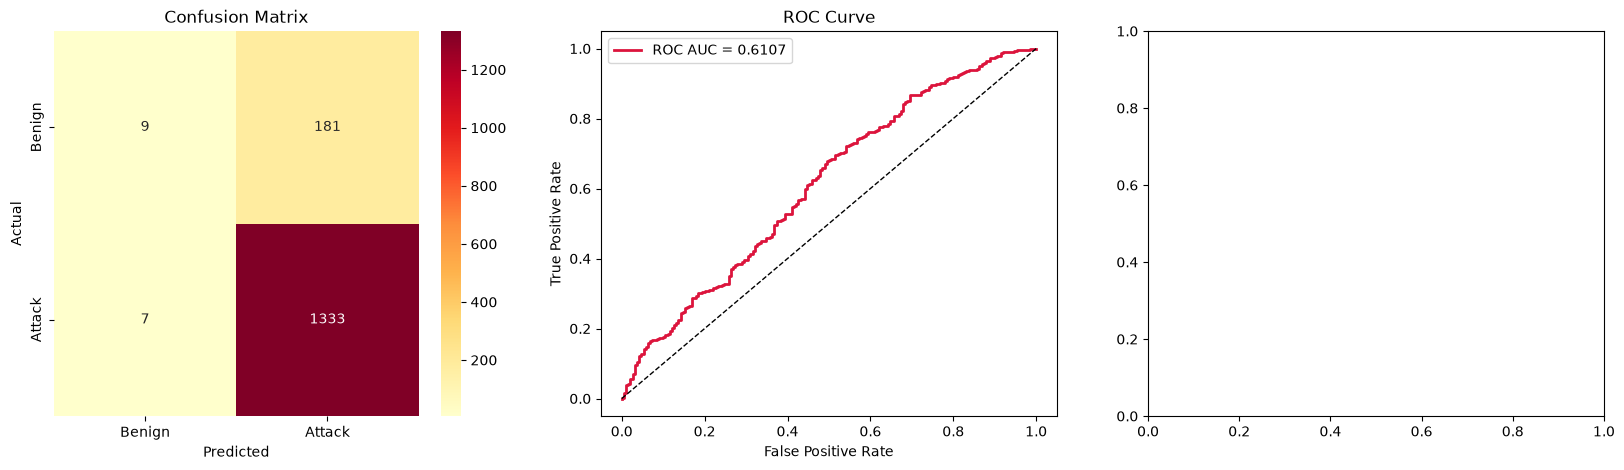

In [ ]:
print("=" * 60)
print("Isolation Forest Anomaly Detector")
print("=" * 60)

model, threshold, metrics = if_mod.train(
    X_pkt_train, y_pkt_train,
    X_pkt_val, y_pkt_val,
    normal_label=NORMAL_LABEL_PKT,
    model_kwargs= {
        "n_estimators":  200,
        "max_samples":   256,
        "contamination": "auto",
        "max_features":  1.0,
    },
    tune_threshold=True,
    save_path=os.path.join(OUTPUT_DIR, "if_anomalyDetector_baseline.joblib")
)

# END of new code

### Supervised Learning - Classification (Model 2)

In [ ]:
attack_mask_tr = np.array(y_train) #!= NORMAL_LABEL
attack_labels  = np.array(y_train) #[attack_mask_tr]
shared_le = LabelEncoder()
shared_le.fit(attack_labels)

print(f"Attack classes ({len(shared_le.classes_)}): {shared_le.classes_}")

In [ ]:
print("=" * 60)
print("XGBoost")
print("=" * 60)

model, metrics, label_eencoder = xgb_mod.train(
    X_train, y_train, X_val, y_val,
    normal_label=NORMAL_LABEL,
    model_kwargs= {
        "n_estimators": 300, "max_depth": 8,
        "learning_rate": 0.1, "subsample": 0.8,
        "colsample_bytree": 0.8, "use_gpu": False,
    },
    label_encoder=shared_le,
    save_path=os.path.join(OUTPUT_DIR, "xgboost.joblib")
)

In [ ]:
print("=" * 60)
print("Random Forest Classifier")
print("=" * 60)

rf_model, rf_metrics = rf_mod.train(
    X_train, y_train,
    X_val,   y_val,
    normal_label=NORMAL_LABEL,
    model_kwargs={
        "n_estimators":  200,
        "max_depth":     None,
        "max_features":  "sqrt",
        "class_weight":  "balanced",
    },
    save_path=os.path.join(OUTPUT_DIR, "random_forest.joblib")
)

In [ ]:
print("=" * 60)
print("Decision Tree Classifier")
print("=" * 60)

dt_model, dt_metrics = dt_mod.train(
    X_train, y_train,
    X_val,   y_val,
    normal_label=NORMAL_LABEL,
    model_kwargs={
        "max_depth":    20,
        "criterion":    "gini",
        "class_weight": "balanced",
    },
    save_path=os.path.join(OUTPUT_DIR, "decision_tree.joblib")
)

In [ ]:
print("=" * 60)
print("K-Nearest Neighbours Classifier")
print("=" * 60)

knn_model, knn_scaler, knn_metrics = knn_mod.train(
    X_train, y_train,
    X_val,   y_val,
    normal_label=NORMAL_LABEL,
    model_kwargs={
        "n_neighbors": 5,
        "weights":     "distance",
        "metric":      "minkowski",
    },
    scale=True,
    save_path=os.path.join(OUTPUT_DIR, "knn.joblib")
)

In [ ]:
print("=" * 60)
print("Multilayer Perceptron Classifier")
print("=" * 60)

mlp_model, mlp_scaler, mlp_metrics = mlp_mod.train(
    X_train, y_train,
    X_val,   y_val,
    normal_label=NORMAL_LABEL,
    model_kwargs={
        "hidden_layer_sizes": (128, 64),
        "activation":         "relu",
        "alpha":              1e-4,
        "max_iter":           300,
        "early_stopping":     True,
    },
    scale=True,
    save_path=os.path.join(OUTPUT_DIR, "mlp.joblib")
)